In [694]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import sklearn

In [695]:
train_data = pd.read_csv('../data/raw/train.csv')
train_data.shape

(8693, 14)

In [696]:
# Этот датафрейм будем изменять
df_train = train_data.copy()
df_train.shape

(8693, 14)

In [697]:
test_data = pd.read_csv('../data/raw/test.csv')
test_data.shape

(4277, 13)

In [698]:
# Этот датафрейм будем изменять
df_test = test_data.copy()
df_test.shape

(4277, 13)

# Compare train и test

In [699]:
train_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [700]:
test_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [701]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [702]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


In [703]:
train_data.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [704]:
test_data.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,4186.000000,4195.000000,4171.000000,4179.000000,4176.000000,4197.000000
mean,28.658146,219.266269,439.484296,177.295525,303.052443,310.710031
std,14.179072,607.011289,1527.663045,560.821123,1117.186015,1246.994742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,53.000000,78.000000,33.000000,50.000000,36.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000


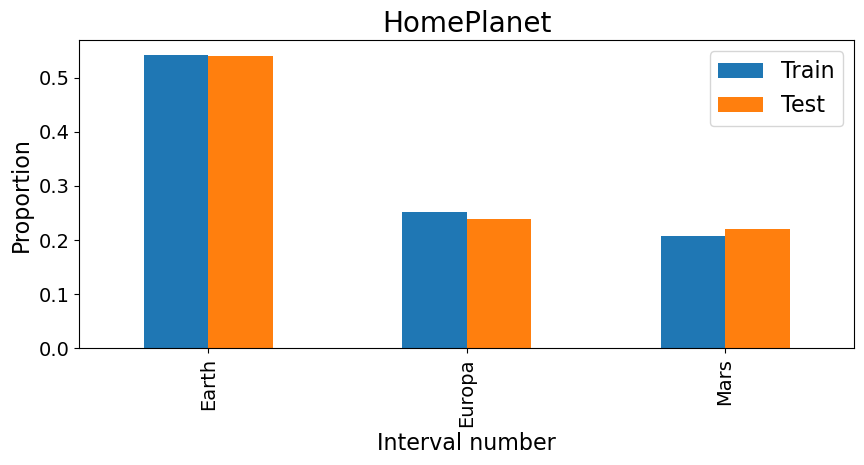

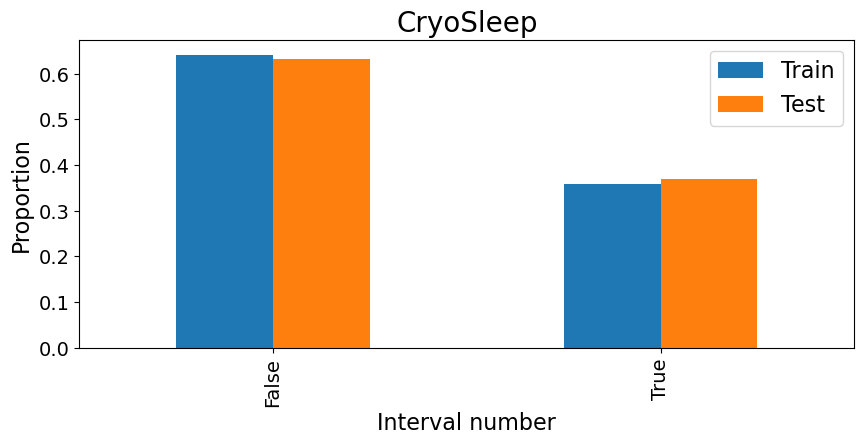

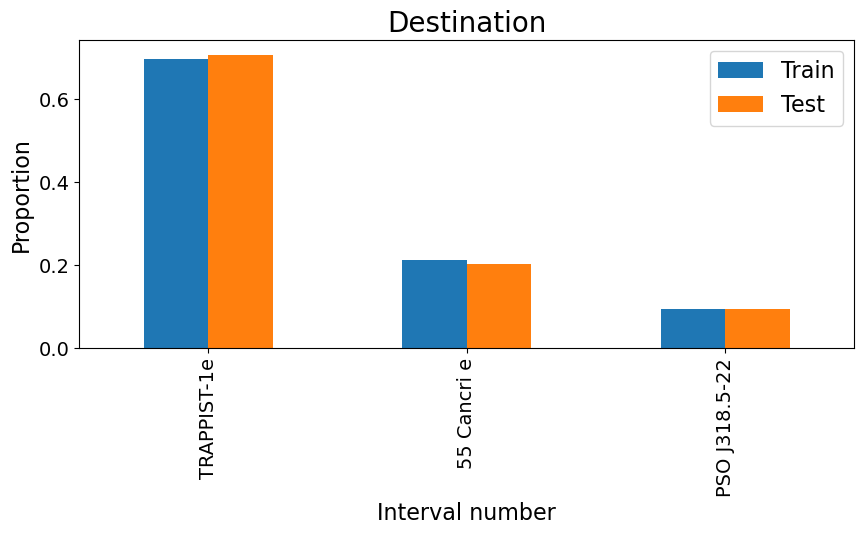

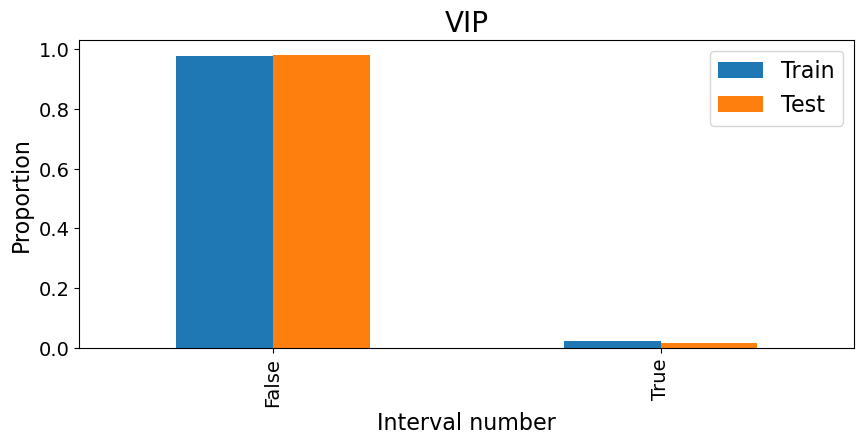

In [705]:
"""
Посмотрим на формы распределений признаков группы и сравним 
их схожесть между тренировочный и тестовым набором
"""
for col in [
    'HomePlanet', 
    'CryoSleep',
    'Destination', 
    'VIP'
]:
    # Считаем пропорцию каждого уникального значения признака в train и test
    train_counts = train_data[col].value_counts(normalize=True)
    test_counts = test_data[col].value_counts(normalize=True)

    """
    Объединяем результаты в DataFrame с двумя столбцами: Train и Test.
    Если какая-то категория встречается только в одной из выборок,
    то для другой ставится NaN, который после объединения заменяется  на 0.
    """
    df_plot = pd.DataFrame({"Train": train_counts, "Test": test_counts}).fillna(0)

    """
    Для сортировки категорий по убыванию доли, создадим столбец суммы частот 
    категорий в train и test.
    """
    df_plot["sum"] = df_plot["Train"] + df_plot["Test"]

    # Сортируем датафрейм и удаляем колонку sum
    df_plot_sorted = df_plot.sort_values(by="sum", ascending=False).drop(columns="sum")

    # Строим bar plot
    ax = df_plot_sorted.plot(kind="bar", figsize=(10, 4))

    # Создаём подписи
    ax.set_title(col, fontsize=20)
    ax.set_xlabel("Interval number", fontsize=16)
    ax.set_ylabel("Proportion", fontsize=16)

    # Задаём размер чисел на графике
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)

    ax.legend(fontsize=16)
    plt.show()

In [706]:
train_data.Cabin.describe()

count        8494
unique       6560
top       G/734/S
freq            8
Name: Cabin, dtype: object

In [707]:
train_data.Cabin.value_counts().head(30)

Cabin
G/734/S     8
F/1194/P    7
B/11/S      7
G/109/P     7
E/13/S      7
D/176/S     7
F/1411/P    7
C/21/P      7
G/1368/P    7
B/201/P     7
B/82/S      7
C/137/S     7
G/981/S     7
G/1476/S    7
C/42/P      6
G/150/S     6
D/56/P      6
E/0/S       6
B/183/S     6
G/292/S     6
A/67/P      6
G/383/S     6
G/765/S     6
F/1808/P    6
G/974/P     6
G/377/P     6
G/117/S     6
C/125/S     6
G/1460/S    6
G/657/P     6
Name: count, dtype: int64

In [708]:
test_data.Cabin.value_counts().head(30)

Cabin
G/160/P     8
E/228/S     7
G/748/S     7
B/31/P      7
D/273/S     7
C/295/P     6
C/177/S     6
B/72/S      6
G/1052/P    6
G/587/P     6
B/214/P     6
G/591/P     6
F/579/P     6
G/737/S     6
G/597/P     6
B/242/P     6
D/92/P      6
A/4/S       6
G/73/S      6
C/31/S      6
C/184/P     5
F/645/S     5
F/75/P      5
F/1066/S    5
G/901/S     5
B/345/S     5
G/978/S     5
G/25/P      5
B/327/S     5
C/71/P      5
Name: count, dtype: int64

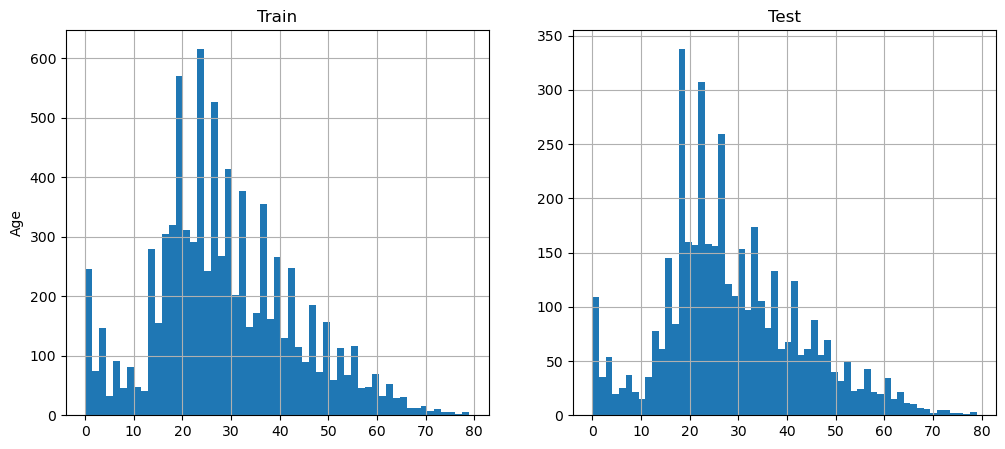

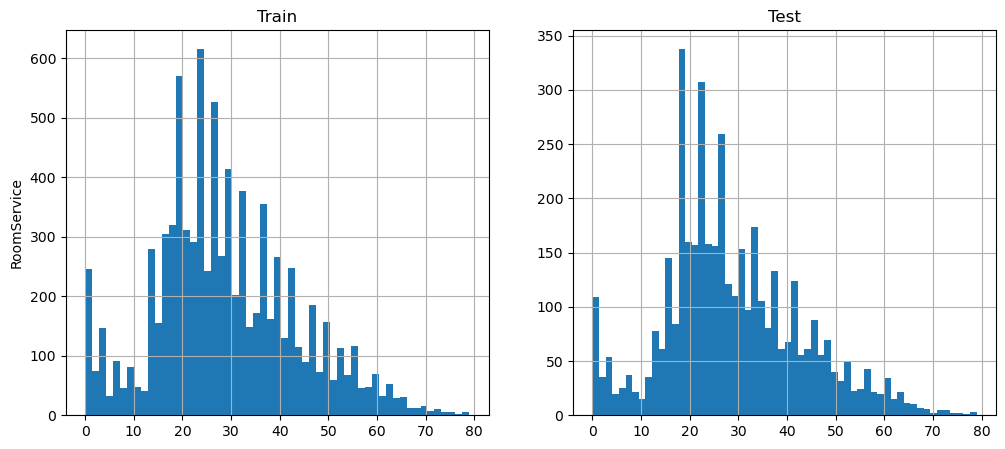

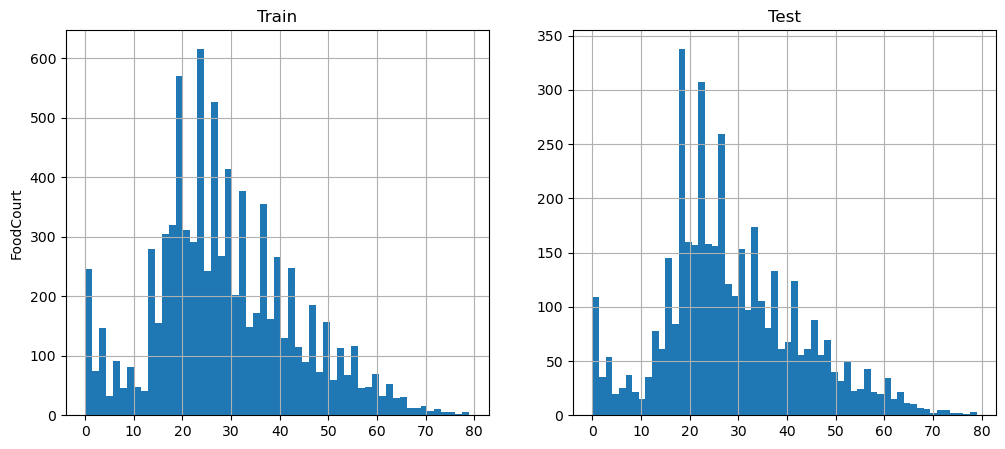

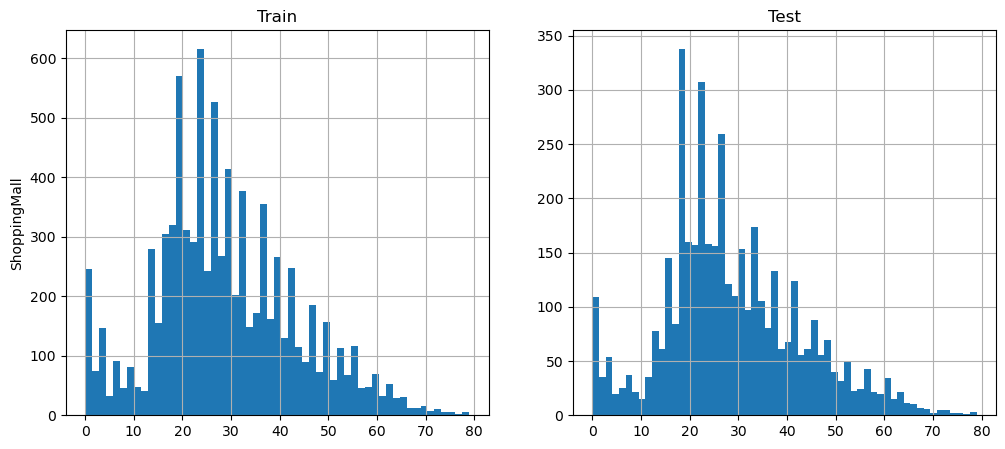

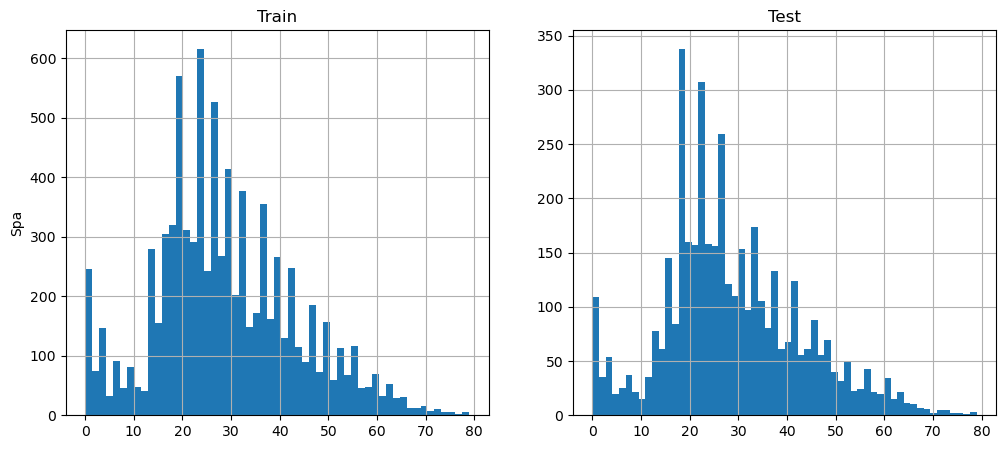

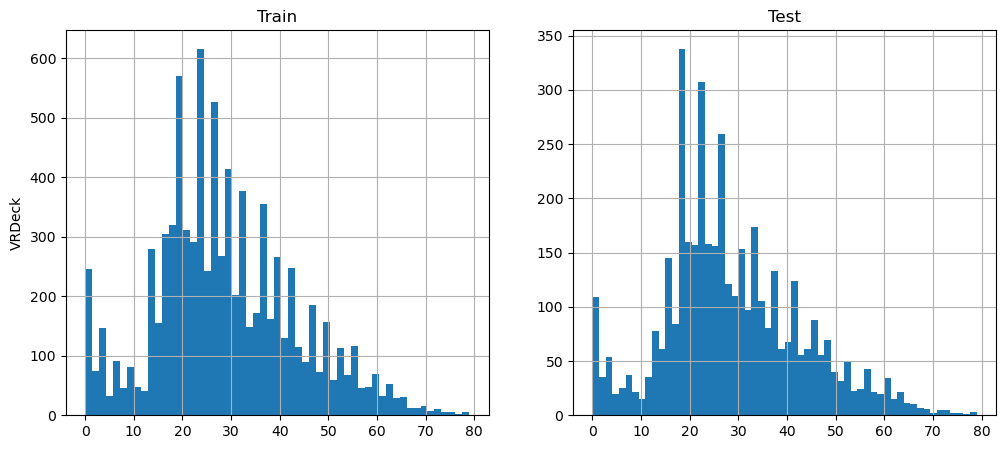

In [709]:
"""
Так как количество уникальных значений признака в train и test наборах отличаются, 
то построим их гистограммы в разных окнах, а для удобного сравнения форм распределений 
зададим каждому графику собственный масштаб (sharey=False)
"""
for col in [
    'Age', 
    'RoomService', 
    'FoodCourt', 
    'ShoppingMall', 
    'Spa', 
    'VRDeck'
]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    
    # Гистограмма для train
    train_data["Age"].hist(bins=55, ax=axes[0])
    axes[0].set_title("Train")
    axes[0].set_ylabel(col)
    
    # Гистограмма для test
    test_data["Age"].hist(bins=58, ax=axes[1])
    axes[1].set_title("Test")
    
    plt.show()

# Target destrebution

In [710]:
train_data.Transported.value_counts(dropna=False)

Transported
True     4378
False    4315
Name: count, dtype: int64

# Cat Features destrebution

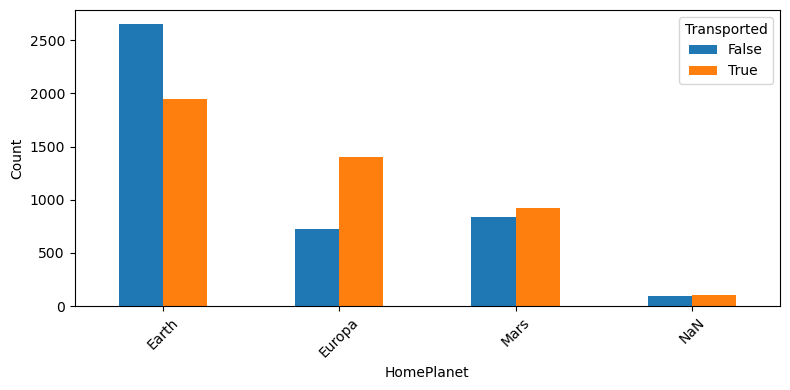

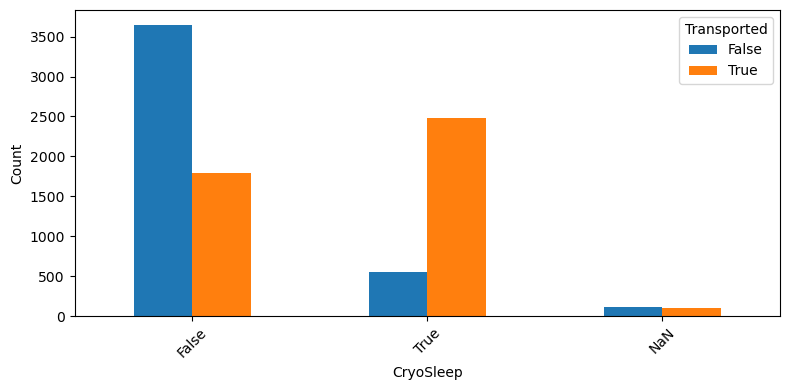

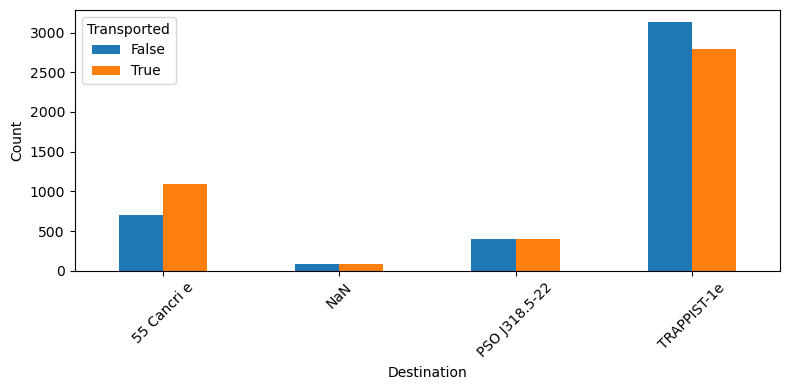

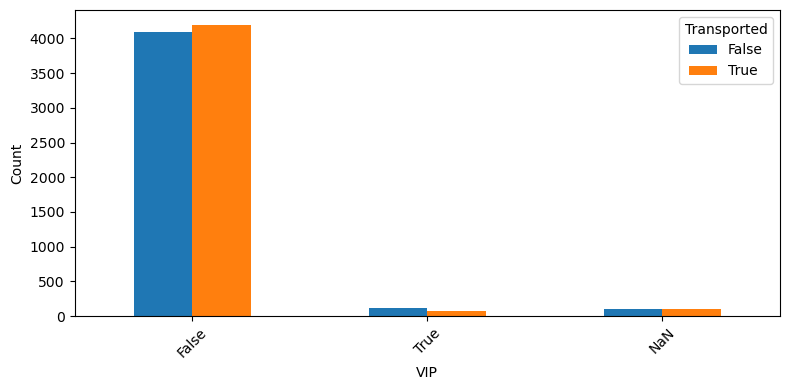

In [711]:
columns = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
target_col = "Transported"
for col in columns:
    tmp = train_data.copy()
    tmp[col] = tmp[col].fillna("NaN")
    
    counts = (
        tmp
        .groupby([col, target_col])
        .size()
        .unstack(fill_value=0)
    )
    
    ax = counts.plot(kind="bar", figsize=(8, 4))
    
    ax.set_ylabel("Count")
    ax.set_xlabel(col)
    ax.legend(title=target_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Numerical features destrebution

In [759]:
cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "Transported"]

In [760]:
for col in cols:
    n_null = train_data[col].isna().sum()
    print(col, n_null)

Age 179
RoomService 181
FoodCourt 183
ShoppingMall 208
Spa 183
VRDeck 188
Transported 0


In [761]:
df_corr = train_data[cols].corr()
df_corr

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
Age,1.000000,0.068723,0.130421,0.033133,0.123970,0.101007,-0.075026
RoomService,0.068723,1.000000,-0.015889,0.054480,0.010080,-0.019581,-0.244611
FoodCourt,0.130421,-0.015889,1.000000,-0.014228,0.221891,0.227995,0.046566
ShoppingMall,0.033133,0.054480,-0.014228,1.000000,0.013879,-0.007322,0.010141
Spa,0.123970,0.010080,0.221891,0.013879,1.000000,0.153821,-0.221131
VRDeck,0.101007,-0.019581,0.227995,-0.007322,0.153821,1.000000,-0.207075
Transported,-0.075026,-0.244611,0.046566,0.010141,-0.221131,-0.207075,1.000000


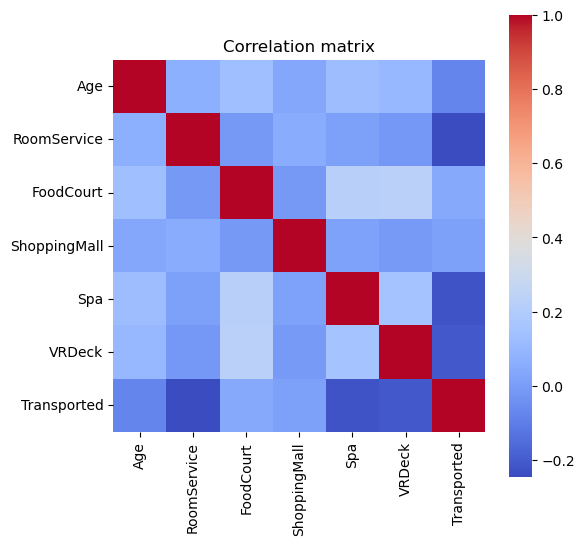

In [762]:
# Визуализация корреляционной матрицы
plt.figure(figsize=(6, 6))
sns.heatmap(df_corr, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation matrix")
plt.show()

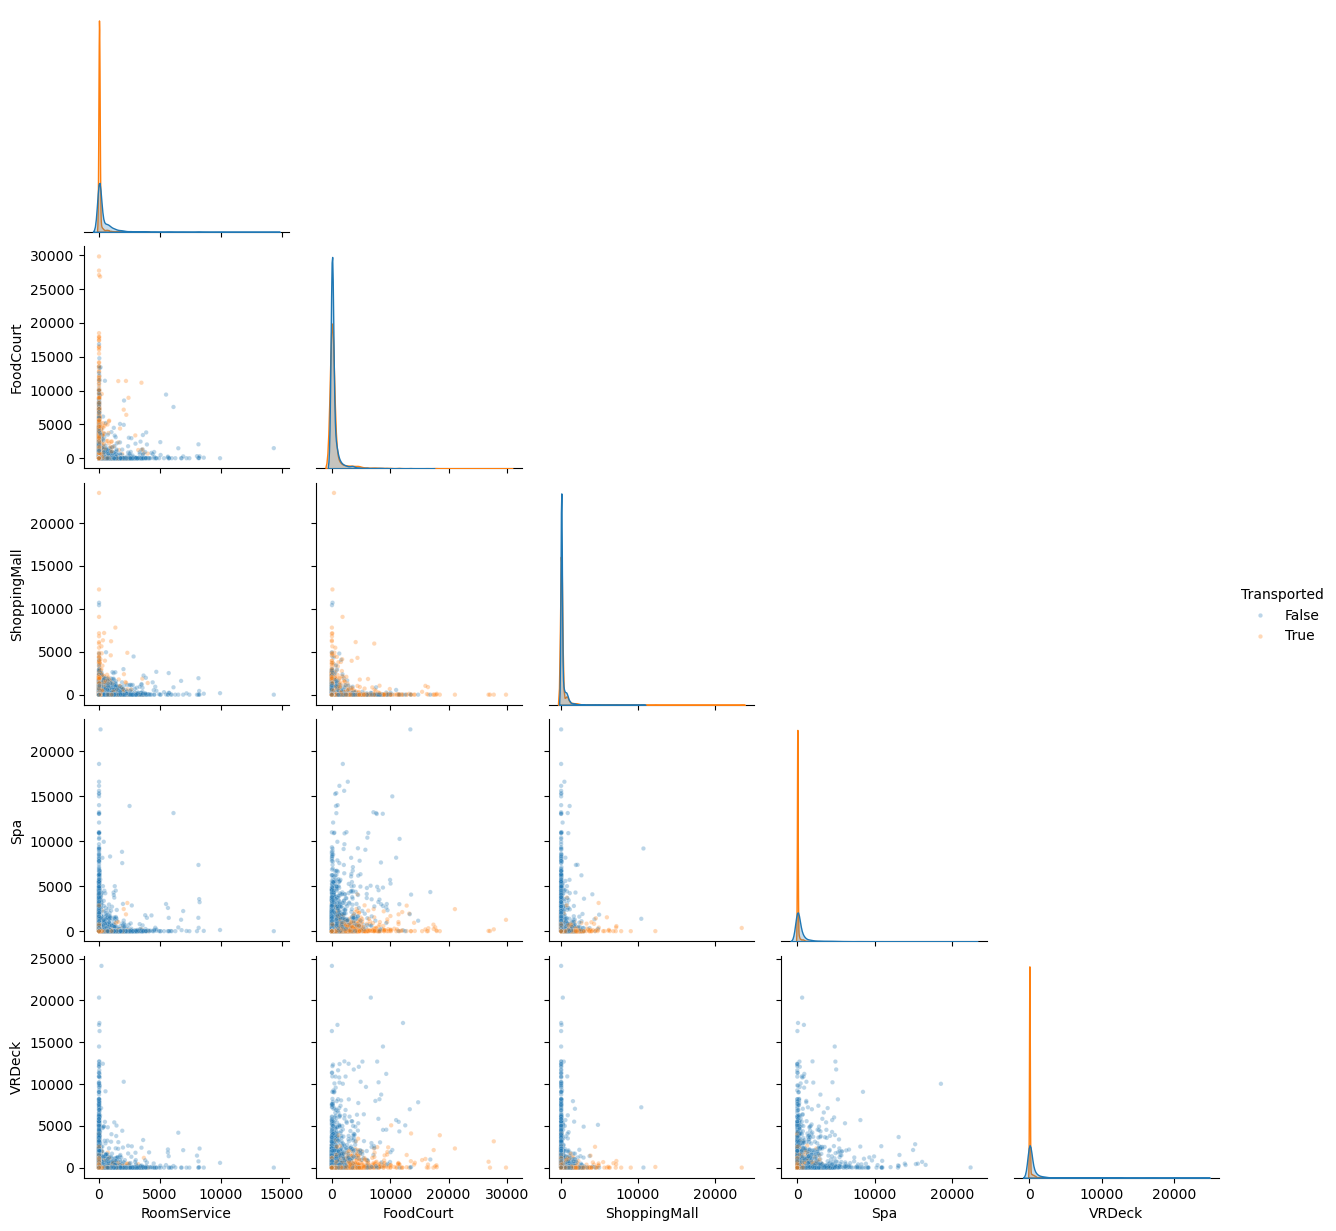

In [716]:
num_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

sns.pairplot(
    train_data,
    vars=num_cols,
    hue="Transported",
    corner=True,
    plot_kws={"alpha": 0.3, "s": 10}
)
plt.show()

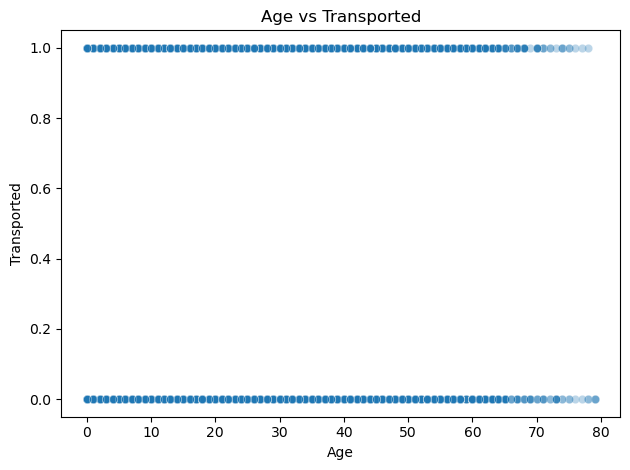

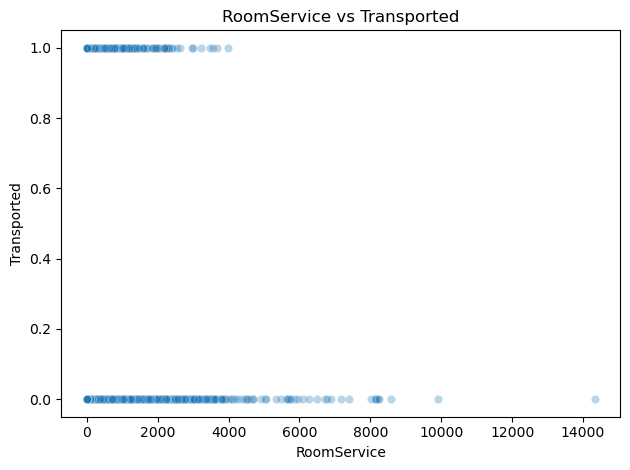

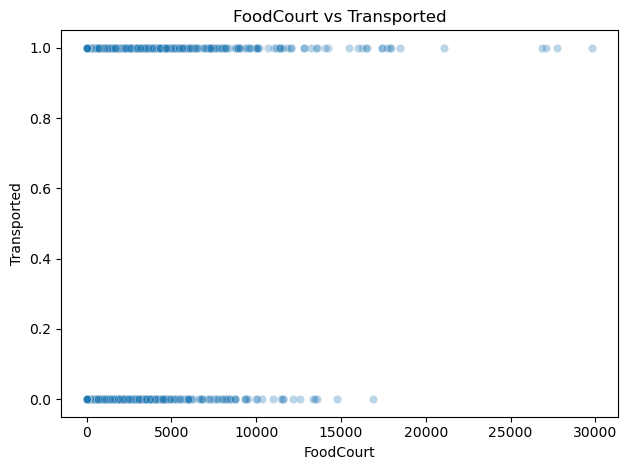

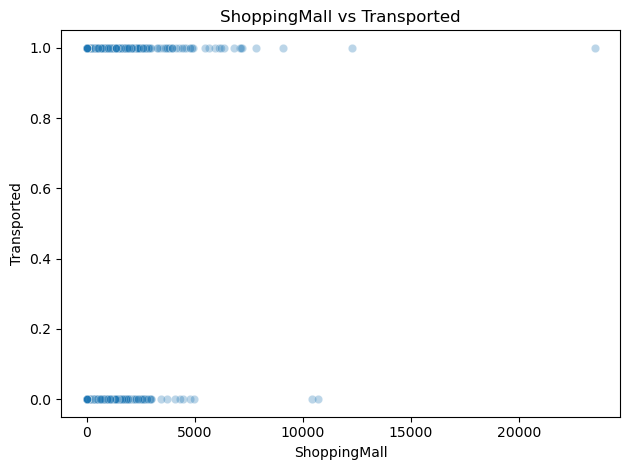

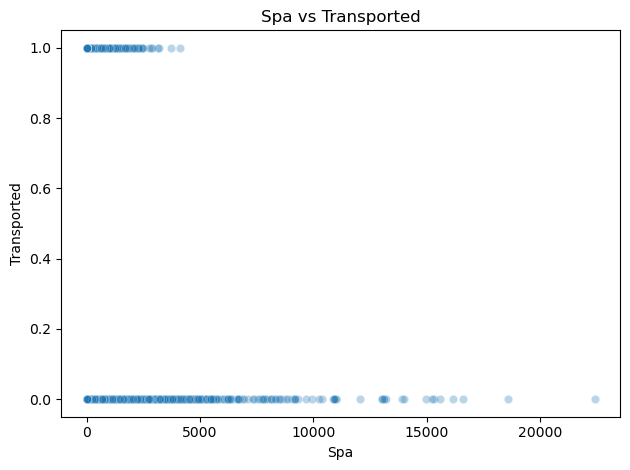

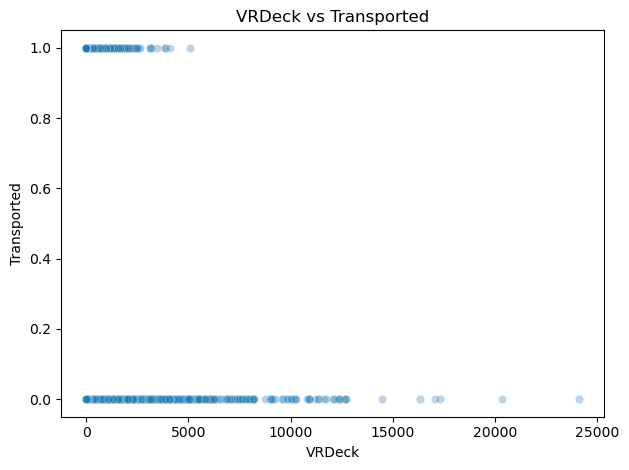

In [717]:
for col in cols:
    sns.scatterplot(
    data=train_data,
    x=col,
    y="Transported",
    alpha=0.3
)
    plt.title(f"{col} vs Transported")
    plt.tight_layout()
    plt.show()

# Filling NaN

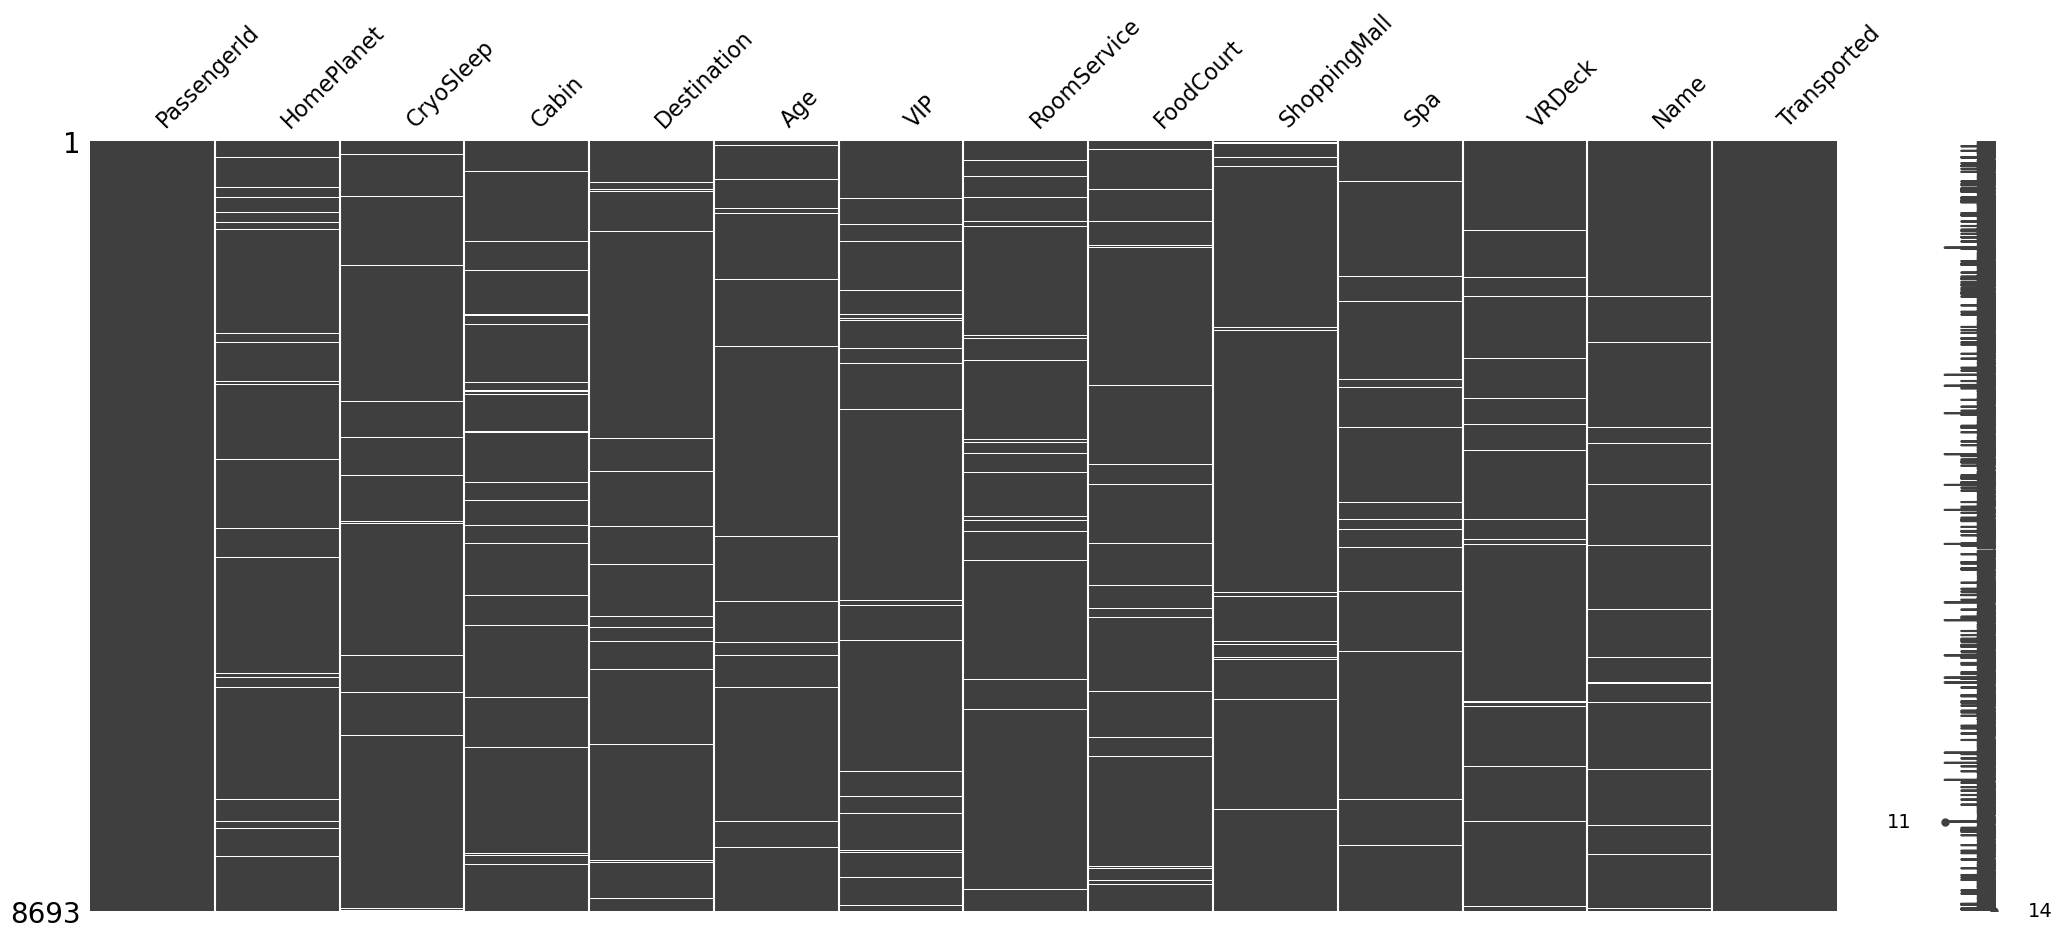

In [718]:
msno.matrix(train_data);

In [719]:
percent = round(train_data.isna().sum().values.sum() / train_data.shape[0] * 100)
print(f'Пропуски в {percent}% строк датасета')

Пропуски в 27% строк датасета


## CryoSleep

In [720]:
df_train[df_train["CryoSleep"].isna()].shape[0]

217

In [721]:
df_test[df_test["CryoSleep"].isna()].shape[0]

93

In [722]:
# Посмотрим были ли люди которые платили  в криосне
# Видим что нет
for col in ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    print(
        col,
        df_train[
        (df_train["CryoSleep"] == True)
        & (df_train[col] != 0)
        & (df_train[col].notna())
        ].shape[0]
    )

RoomService 0
FoodCourt 0
ShoppingMall 0
Spa 0
VRDeck 0


In [723]:
df_train.CryoSleep.value_counts()

CryoSleep
False    5439
True     3037
Name: count, dtype: int64

In [724]:
# Посмотрим были ли люди которые НЕ платили  НЕ в криосне
# Видим что таких примерно половина, значит отсутствие платежей не очень надёжный 
# предиктор криосна, но за неимением лучшего воспользуемся им
for col in ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    print(
        col,
        df_train[
        (df_train["CryoSleep"] == False)
        & (df_train[col] == 0)
        & (df_train[col].notna())
        ].shape[0]
    )

RoomService 2464
FoodCourt 2354
ShoppingMall 2502
Spa 2218
VRDeck 2381


In [725]:
mask_true = (df_train["CryoSleep"].isna()) & (df_train["RoomService"] == 0)
mask_false = df_train["CryoSleep"].isna() & (df_train["RoomService"] != 0)

df_train.loc[mask_true, "CryoSleep"] = True
df_train.loc[mask_false, "CryoSleep"] = False

print(f"Пустых строк осталось {df_train[df_train["CryoSleep"].isna()].shape[0]}")

Пустых строк осталось 0


In [726]:
mask_true = (df_test["CryoSleep"].isna()) & (df_test["RoomService"] == 0)
mask_false = df_test["CryoSleep"].isna() & (df_test["RoomService"] != 0)

df_test.loc[mask_true, "CryoSleep"] = True
df_test.loc[mask_false, "CryoSleep"] = False

df_test[df_test["CryoSleep"].isna()].shape[0]

0

## HomePlanet

In [727]:
df_train[df_train["HomePlanet"].isna()].shape[0]

201

In [728]:
df_test[df_test["HomePlanet"].isna()].shape[0]

87

/var/folders/mz/qh51y5312sv4n7c523cx3j240000gn/T/ipykernel_23969/3529226938.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tmp[col] = tmp[col].fillna("NaN")


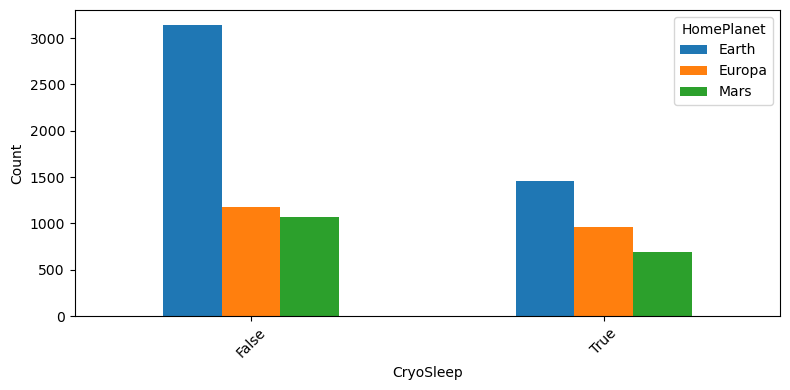

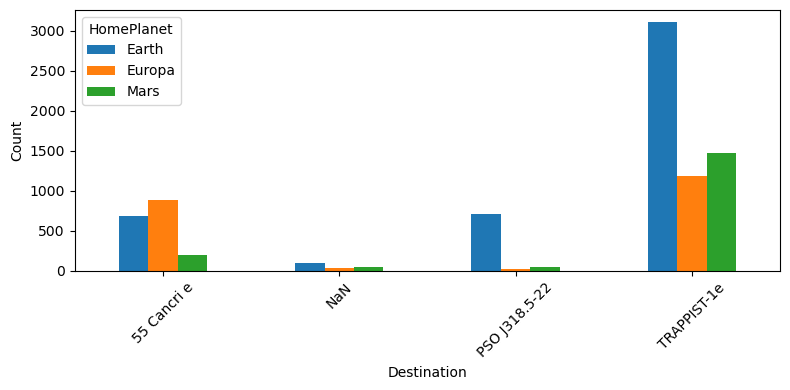

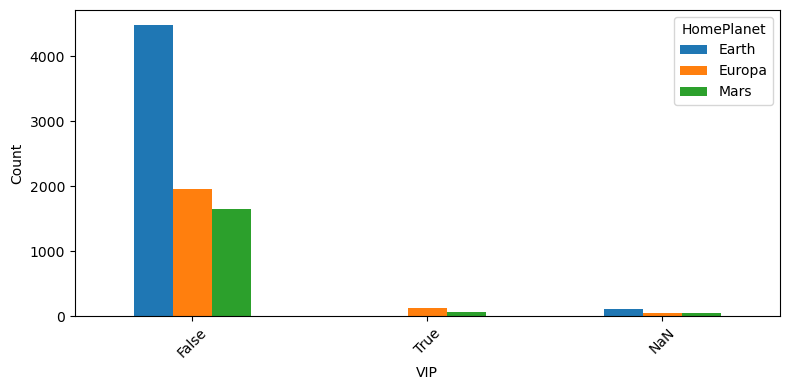

In [729]:
columns = ["CryoSleep", "Destination", "VIP"]
target_col = "HomePlanet"
for col in columns:
    tmp = df_train.copy()
    tmp[col] = tmp[col].fillna("NaN")
    
    counts = (
        tmp
        .groupby([col, target_col])
        .size()
        .unstack(fill_value=0)
    )
    
    ax = counts.plot(kind="bar", figsize=(8, 4))
    
    ax.set_ylabel("Count")
    ax.set_xlabel(col)
    ax.legend(title=target_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Заполним пропуски в HomePlanet.      
Если человек с Земли, то он скорее НЕ был в криосне.  
Если человек с Земли, то он летел скорее на Трапписит.  
Если человек с Земли, то у него нет VIP.

In [730]:
# Ищем совпадения по тем кто предположительно летел с Земли у трёх признаков
mask_true = ( 
    df_train["HomePlanet"].isna()
    & (df_train["CryoSleep"] == False)
    & (df_train["Destination"].notna()) & (df_train["Destination"] == "TRAPPIST-1e")
    & (df_train["VIP"].notna()) & (df_train["VIP"] == False)   
)
mask_true.value_counts()

False    8597
True       96
Name: count, dtype: int64

Так как людей с Земли большинство, то и остальные пропуски заполним ими

In [731]:
df_train['HomePlanet'] = df_train['HomePlanet'].fillna("Earth")
df_train[df_train["HomePlanet"].isna()].shape[0]

0

In [732]:
df_test['HomePlanet'] = df_test['HomePlanet'].fillna("Earth")
df_test[df_test["HomePlanet"].isna()].shape[0]

0

## Destination

In [733]:
df_train[df_train["Destination"].isna()].shape[0]

182

In [734]:
df_test[df_test["Destination"].isna()].shape[0]

92

/var/folders/mz/qh51y5312sv4n7c523cx3j240000gn/T/ipykernel_23969/3435289410.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tmp[col] = tmp[col].fillna("NaN")


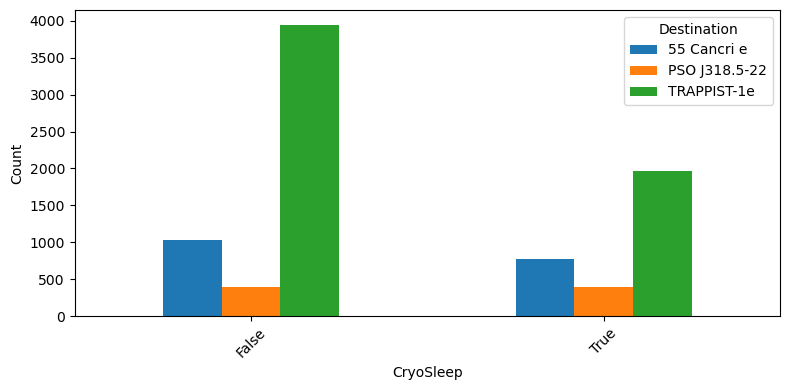

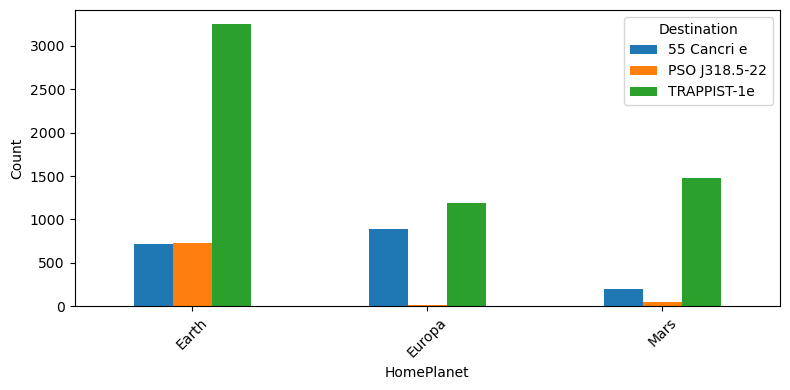

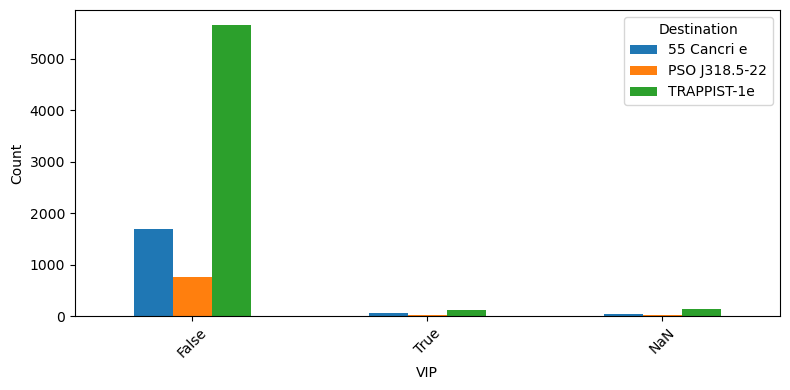

In [735]:
columns = ["CryoSleep", "HomePlanet", "VIP"]
target_col = "Destination"
for col in columns:
    tmp = df_train.copy()
    tmp[col] = tmp[col].fillna("NaN")
    
    counts = (
        tmp
        .groupby([col, target_col])
        .size()
        .unstack(fill_value=0)
    )
    
    ax = counts.plot(kind="bar", figsize=(8, 4))
    
    ax.set_ylabel("Count")
    ax.set_xlabel(col)
    ax.legend(title=target_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Если человек летит на Траписит, то он скорее НЕ VIP.  
Если человек летит на Траписит, то он скорее всего с Земли или с Марса.  
Если человек летит на Траписит, то он скорее всего не был в криосне.

In [736]:
# Ищем совпадения по тем кто предположительно летел на Трапписит у трёх признаков
mask_true = ( 
    df_train["Destination"].isna()
    & (df_train["CryoSleep"] == False)
    & (df_train["HomePlanet"].notna()) & (df_train["HomePlanet"] == "Earth")
    & (df_train["VIP"].notna()) & (df_train["VIP"] == False)   
)
mask_true.value_counts()

False    8607
True       86
Name: count, dtype: int64

Так как  большинство людей летит на 'TRAPPIST-1e' , то и остальные пропуски заполним ими

In [737]:
df_train['Destination'] = df_train['Destination'].fillna("'TRAPPIST-1e'")
df_train[df_train["Destination"].isna()].shape[0]

0

In [738]:
df_test['Destination'] = df_test['Destination'].fillna("'TRAPPIST-1e'")
df_test[df_test["Destination"].isna()].shape[0]

0

## VIP

In [739]:
df_train[df_train["VIP"].isna()].shape[0]

203

In [740]:
df_test[df_test["VIP"].isna()].shape[0]

93

Создадим общий признак трат и посмотрим на распределение VIP в нём

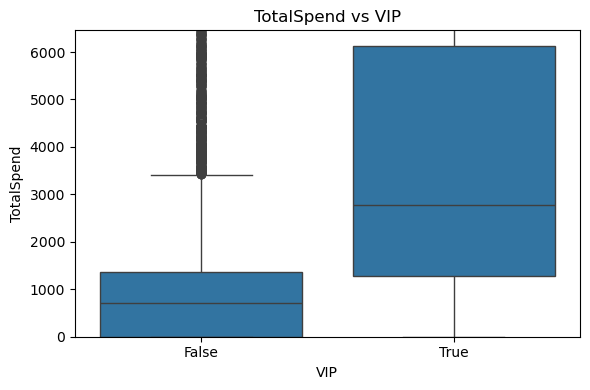

In [741]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
df_train["TotalSpend"] = df_train[spend_cols].sum(axis=1)
df_test["TotalSpend"] = df_test[spend_cols].sum(axis=1)

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df_train,
    x="VIP",         
    y="TotalSpend"
)
plt.ylim(0, df_train["TotalSpend"].quantile(0.95))  # обрежем самые жирные хвосты, чтобы было видно «тело»
plt.title("TotalSpend vs VIP")
plt.tight_layout()
plt.show()

In [742]:
# Порог для трейна и теста вычислим по трейну
thr = df_train.loc[df_train["VIP"] == True, "TotalSpend"].median()
thr

2767.0

In [743]:
mask_nan = df_train["VIP"].isna()
df_train.loc[mask_nan & (df_train["TotalSpend"] >= thr), "VIP"] = True
df_train.loc[mask_nan & (df_train["TotalSpend"] <  thr), "VIP"] = False
df_train[df_train["VIP"].isna()].shape[0]

0

In [744]:
mask_nan = df_test["VIP"].isna()
df_test.loc[mask_nan & (df_test["TotalSpend"] >= thr), "VIP"] = True
df_test.loc[mask_nan & (df_test["TotalSpend"] <  thr), "VIP"] = False
df_test[df_test["VIP"].isna()].shape[0]

0

## Cabin

In [745]:
# Создадидим признаки палубы, каюты и стороны
cabin_split = df_train["Cabin"].str.split("/", expand=True)
cabin_split.columns = ["deck", "cabin_num", "side"]

df_train["deck"] = cabin_split["deck"]
df_train["cabin_num"] = pd.to_numeric(cabin_split["cabin_num"], errors="coerce")
df_train["side"] = cabin_split["side"]
df_train.shape

(8693, 18)

In [746]:
# Создадидим признаки палубы, каюты и стороны
cabin_split = df_test["Cabin"].str.split("/", expand=True)
cabin_split.columns = ["deck", "cabin_num", "side"]

df_test["deck"] = cabin_split["deck"]
df_test["cabin_num"] = pd.to_numeric(cabin_split["cabin_num"], errors="coerce")
df_test["side"] = cabin_split["side"]
df_test.shape

(4277, 17)

In [747]:
df_train["deck"].value_counts(dropna=False)

deck
F      2794
G      2559
E       876
B       779
C       747
D       478
A       256
NaN     199
T         5
Name: count, dtype: int64

In [748]:
df_train["deck"] = df_train["deck"].fillna('U')
df_train["deck"] = df_train["deck"].fillna('U')

In [749]:
df_train["cabin_num"].value_counts(dropna=False)

cabin_num
NaN       199
82.0       28
19.0       22
86.0       22
97.0       21
         ... 
1839.0      1
1848.0      1
1847.0      1
1749.0      1
1880.0      1
Name: count, Length: 1818, dtype: int64

In [750]:
med = df_train["cabin_num"].median()
print(med)
df_train["cabin_num"] = df_train["cabin_num"].fillna(med)

427.0


In [751]:
med = df_test["cabin_num"].median()
print(med)
df_test["cabin_num"] = df_test["cabin_num"].fillna(med)

442.0


In [752]:
df_train["side"].value_counts(dropna=False)

side
S      4288
P      4206
NaN     199
Name: count, dtype: int64

In [753]:
df_train["side"] = df_train["side"].fillna('U')
df_test["side"] = df_test["side"].fillna('U')

In [754]:
df_train["Cabin"] = df_train["Cabin"].fillna('Unknown')
df_test["Cabin"] = df_test["Cabin"].fillna('Unknown')

## Numerical features

In [755]:
# Медианы для трейна и теста вычислим по трейну
num_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

for col in num_cols:
    med = df_train[col].median()
    print(col, med)
    
    df_train[col] = df_train[col].fillna(med)
    df_test[col] = df_test[col].fillna(med)

Age 27.0
RoomService 0.0
FoodCourt 0.0
ShoppingMall 0.0
Spa 0.0
VRDeck 0.0


## Name

In [756]:
df_train = df_train.drop('Name', axis=1)
df_test = df_test.drop('Name', axis=1)
df_train.shape, df_test.shape

((8693, 17), (8693, 17))